Phase3_Salah_TimeSeries.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1OF-FbTmeg8ISh6Slzt4DuR794LQuc2ff

# New Section

Matches found: 52
Example line: 2022-07-30        17:00 (19:00)        Community Shield        FA Community Shield        Sat        Neutral        W        3        1        Manchester City        3        15        4        26.7        0.13        0.50                        1        1                                                Match Report
Row length range: (19, 26)
df_clean shape: (52, 26)


,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Extra
0,2022-07-30,17:00 (19:00),Community Shield,FA Community Shield,Sat,Neutral,W,3,1,Manchester City,...,1,1,Match Report,None,None,None,None,None,None,None
1,2022-08-06,12:30 (14:30),Premier League,Matchweek 1,Sat,Away,D,2,2,Fulham,...,12.4,0,0,0,1.2,1.2,0.11,+0.8,+0.8,Match Report
2,2022-08-15,20:00 (22:00),Premier League,Matchweek 2,Mon,Home,D,1,1,Crystal Palace,...,17.4,0,0,0,2.0,2.0,0.09,-1.0,-1.0,Match Report
3,2022-08-22,20:00 (22:00),Premier League,Matchweek 3,Mon,Away,L,1,2,Manchester Utd,...,14.4,0,0,0,1.3,1.3,0.08,-0.3,-0.3,Match Report
4,2022-08-27,15:00 (17:00),Premier League,Matchweek 4,Sat,Home,W,9,0,Bournemouth,...,11.6,0,0,0,3.3,3.3,0.18,+4.7,+4.7,Match Report


Final X shape: (46, 6)
Final y shape: (46,)
Using features: ['Sh', 'SoT', 'xG', 'npxG', 'Dist', 'SoT_per_Sh']
Train: (27, 6) Val: (9, 6) Test: (10, 6)
Best RF Params: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


,Split,Model,MSE,RMSE,MAE,R2
0,Validation,Linear Regression,0.916454,0.957316,0.814146,0.136829
1,Validation,Random Forest (Tuned),1.681867,1.296868,1.051824,-0.584084


,Split,Model,MSE,RMSE,MAE,R2
0,Test,Linear Regression,0.640737,0.800460,0.713223,0.373363
1,Test,Random Forest (Tuned),0.733281,0.856319,0.731161,0.282854


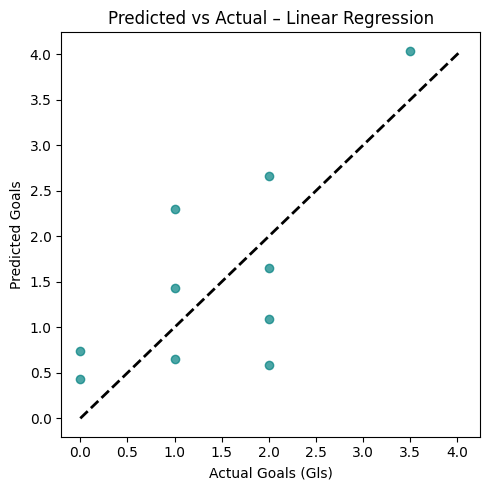

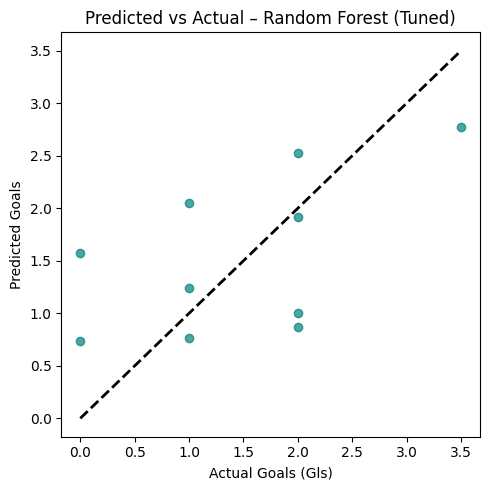

In [3]:
# -*- coding: utf-8 -*-

# =========================
# Phase 2 - Liverpool Goals Prediction (Regression) - UPDATED
# Includes: Train/Val/Test, Feature Engineering, Outliers handling, GridSearchCV tuning, full plots
# =========================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# -------------------------
# 1) Read raw text file
# -------------------------
with open("/content/liverpool.csv.csv", "r", encoding="utf-8") as f:
    raw_text = f.read()

# -------------------------
# 2) Extract match lines (each line starts with YYYY-MM-DD)
# -------------------------
lines = raw_text.split("\n")
match_lines = [l.strip() for l in lines if re.match(r"^\d{4}-\d{2}-\d{2}", l)]

print("Matches found:", len(match_lines))
print("Example line:", match_lines[0] if match_lines else "None")

# -------------------------
# 3) Split each match line into columns
# -------------------------
rows = [re.split(r"\s{2,}", line) for line in match_lines]
max_len = max(len(r) for r in rows)
min_len = min(len(r) for r in rows)
print("Row length range:", (min_len, max_len))

rows_fixed = []
for r in rows:
    if len(r) < max_len:
        r = r + [None] * (max_len - len(r))
    else:
        r = r[:max_len]
    rows_fixed.append(r)

# -------------------------
# 4) Create a DataFrame
# -------------------------
all_columns = [
    "Date","Time","Comp","Round","Day","Venue","Result",
    "GF","GA","Opponent",
    "Gls","Sh","SoT","SoT%","G/Sh","G/SoT","Dist",
    "FK","PK","PKatt",
    "xG","npxG","npxG/Sh","G-xG","np:G-xG","Extra"
]

df_clean = pd.DataFrame(rows_fixed, columns=all_columns[:max_len])
print("df_clean shape:", df_clean.shape)
display(df_clean.head())

# -------------------------
# 5) Select features + target
# -------------------------
target = "Gls"
features = ["Sh", "SoT", "xG", "npxG", "Dist"]
features = [c for c in features if c in df_clean.columns]

# Convert numeric columns
for c in features + [target]:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

# Keep only needed columns and drop missing
data = df_clean[features + [target]].dropna().copy()

# -------------------------
# 6) Feature Engineering (simple but useful)
# -------------------------
# نسبة التسديدات على المرمى إلى إجمالي التسديدات
data["SoT_per_Sh"] = data["SoT"] / (data["Sh"] + 1e-6)

# Update feature list
features_fe = features + ["SoT_per_Sh"]

# -------------------------
# 7) Handle anomalous values / outliers (IQR clipping)
# -------------------------
def iqr_clip(df, cols, factor=1.5):
    df_out = df.copy()
    for col in cols:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        df_out[col] = df_out[col].clip(lower, upper)
    return df_out

data = iqr_clip(data, features_fe + [target], factor=1.5)

X = data[features_fe]
y = data[target]

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("Using features:", features_fe)

# -------------------------
# 8) Split: Train / Validation / Test
#    Example: 80% trainval, 20% test then split trainval into 75/25 => train 60%, val 20%, test 20%
# -------------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# -------------------------
# 9) Model 1: Linear Regression (baseline) + scaling
# -------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)

pred_lr_val = lr.predict(X_val_s)
pred_lr_test = lr.predict(X_test_s)

# -------------------------
# 10) Model 2: Random Forest (advanced) + Hyperparameter tuning (GridSearchCV)
# -------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best RF Params:", grid.best_params_)

pred_rf_val = best_rf.predict(X_val)
pred_rf_test = best_rf.predict(X_test)

# -------------------------
# 11) Evaluation functions
# -------------------------
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

# Validation metrics
mse_lr_v, rmse_lr_v, mae_lr_v, r2_lr_v = metrics(y_val, pred_lr_val)
mse_rf_v, rmse_rf_v, mae_rf_v, r2_rf_v = metrics(y_val, pred_rf_val)

val_results = pd.DataFrame({
    "Split": ["Validation", "Validation"],
    "Model": ["Linear Regression", "Random Forest (Tuned)"],
    "MSE": [mse_lr_v, mse_rf_v],
    "RMSE": [rmse_lr_v, rmse_rf_v],
    "MAE": [mae_lr_v, mae_rf_v],
    "R2": [r2_lr_v, r2_rf_v]
})

# Test metrics
mse_lr_t, rmse_lr_t, mae_lr_t, r2_lr_t = metrics(y_test, pred_lr_test)
mse_rf_t, rmse_rf_t, mae_rf_t, r2_rf_t = metrics(y_test, pred_rf_test)

test_results = pd.DataFrame({
    "Split": ["Test", "Test"],
    "Model": ["Linear Regression", "Random Forest (Tuned)"],
    "MSE": [mse_lr_t, mse_rf_t],
    "RMSE": [rmse_lr_t, rmse_rf_t],
    "MAE": [mae_lr_t, mae_rf_t],
    "R2": [r2_lr_t, r2_rf_t]
})

display(val_results)
display(test_results)

# -------------------------
# 12) Plots (Predicted vs Actual) for BOTH models (Test set)
# -------------------------
def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.7, color="teal")
    # رسم خط مطابقة مثالي (x = y) للمقارنة السريعة
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=2)
    plt.xlabel("Actual Goals (Gls)")
    plt.ylabel("Predicted Goals")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Linear Regression plot
plot_pred_vs_actual(y_test, pred_lr_test, "Predicted vs Actual – Linear Regression")

# Random Forest (Tuned) plot
plot_pred_vs_actual(y_test, pred_rf_test, "Predicted vs Actual – Random Forest (Tuned)")